# Experiment 2 — Sanity checks: does the engine reproduce what the literature already knows?

> **⚠ ALL DATA IS SYNTHETIC** (the final section runs on a real *topology* with synthetic
> agents — clearly marked). See [`docs/limitations.md`](../docs/limitations.md).

Before trusting any new claim from a simulator, check it against settled results. This
notebook replicates three canonical findings **qualitatively** (shapes and orderings, not
numbers), runs the sensitivity tornado for the headline result, and tests robustness to
the credibility-weight assumption. Verdicts are mirrored in
[`docs/sanity-checks.md`](../docs/sanity-checks.md) — including what the model does
**not** reproduce.

| # | Reference result | Source |
|---|---|---|
| 1 | Tiny threshold-distribution changes flip collective outcomes | Granovetter 1978 |
| 2 | Complex contagion travels clustered networks, dies on random ones; the reverse for simple contagion | Centola & Macy 2007; Centola 2010 |
| 3 | Single-seed cascades need θ below ~1/z (vulnerable nodes) | Watts 2002 |

Expected runtime: **~2 minutes** (multi-core). Each section is self-contained.

In [1]:
import sys, pathlib, time, json
HERE = pathlib.Path.cwd().resolve()
REPO = HERE if (HERE / "core").exists() else HERE.parent
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / "experiments"))

import numpy as np, networkx as nx, matplotlib.pyplot as plt
import core, exp1, plotting
from core import defaults
from core.dynamics import SimParams, run_simulation, draw_agents
from core.orggen import OrgGraph
from core.seeding import Seeding, make_seeding
from core.scenario import set_path, org_kwargs, build_sim_params

T0 = time.time()
VERDICTS = {}

def wrap(g, team=None):
    """Wrap a bare NetworkX graph (unit weights) for the engine."""
    g = nx.convert_node_labels_to_integers(g, ordering="sorted")
    for n in g.nodes():
        g.nodes[n].update(team=int(team[n]) if team is not None else 0,
                          dept=0, role=0, tenure=5.0)
    for _, _, d in g.edges(data=True):
        d.setdefault("weight", 1.0)
    return OrgGraph(formal=g, informal=g, params={"kind": "synthetic-benchmark"}).compile()

def exact_agents(n, theta):
    t = np.full(n, theta, float) if np.isscalar(theta) else np.asarray(theta, float)
    return t, np.ones(n, bool), np.ones(n, bool)

def seeds(*ids):
    return Seeding("explicit", np.array(ids, dtype=np.int64), False, {})

PARAMS_FAST = SimParams(max_steps=120)
print(f"adoption-sim {core.__version__} · checks use exact thresholds (no draws) unless stated")

adoption-sim 0.1.0 · checks use exact thresholds (no draws) unless stated


## Check 1 — Granovetter (1978): the fragile riot

Complete graph of 100 agents, thresholds laid out as a uniform grid θᵢ = i/100, one
instigator seeded. The grid is a perfect domino run: each adoption pushes exactly the
next person over. Then the minimal perturbation — person #1's threshold moved from
0.01 to 0.5 — and the same crowd does nothing. **Expected:** full cascade vs. cascade
of one; the famous knife-edge.

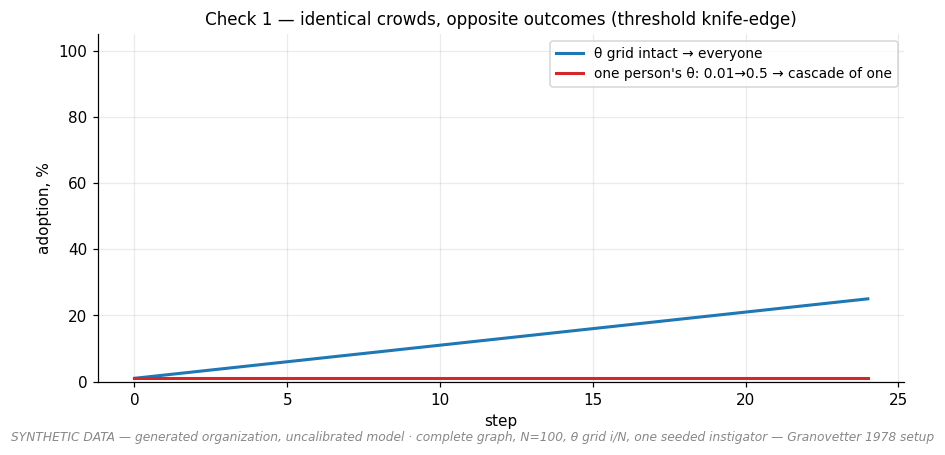

intact: 100% · gapped: 1% → PASS


In [2]:
n = 100
cg = wrap(nx.complete_graph(n))
theta_grid = np.arange(n) / n
r_intact = run_simulation(cg, PARAMS_FAST, seeds(0), rng=1, agents=exact_agents(n, theta_grid))
theta_gap = theta_grid.copy(); theta_gap[1] = 0.5
r_gapped = run_simulation(cg, PARAMS_FAST, seeds(0), rng=1, agents=exact_agents(n, theta_gap))

fig, ax = plotting.fig_with_stamp(figsize=(8, 4),
    note="complete graph, N=100, θ grid i/N, one seeded instigator — Granovetter 1978 setup")
ax.plot(100 * r_intact.curve[:25], color="#1f77b4", lw=2, label="θ grid intact → everyone")
ax.plot(100 * r_gapped.curve[:25], color="#d62728", lw=2,
        label="one person's θ: 0.01→0.5 → cascade of one")
ax.set_xlabel("step"); ax.set_ylabel("adoption, %"); ax.set_ylim(0, 105)
ax.set_title("Check 1 — identical crowds, opposite outcomes (threshold knife-edge)", fontsize=11)
ax.legend(fontsize=9)
plt.show()
ok = r_intact.final_rate == 1.0 and r_gapped.final_rate <= 0.02
VERDICTS["granovetter_knife_edge"] = "PASS" if ok else "FAIL"
print(f"intact: {r_intact.final_rate:.0%} · gapped: {r_gapped.final_rate:.0%} → {VERDICTS['granovetter_knife_edge']}")

## Check 2 — Centola & Macy (2007): the weakness of long ties

Same population, same θ = 0.25 for everyone, and the canonical seed: **one focal node
plus its entire neighborhood** (Centola & Macy's perturbation — 9 nodes here). Two
topologies: a ring lattice (every node tied to its 8 nearest: overlapping
neighborhoods, **wide bridges**) and a degree-matched random graph (no triangles,
**narrow bridges**). Complex contagion must spread on the lattice and die on the
random graph — on the random graph nobody outside the seed neighborhood has more than
~one tie into it. For *simple* contagion (θ = 0.10 < 1/8) the ordering must **flip**:
random shortcuts win on speed. (A first version of this check seeded 5% at random and
the random graph cascaded — correctly so: dense random seeding sits *above* the
complex-contagion percolation threshold. The check is about localized seeding.)

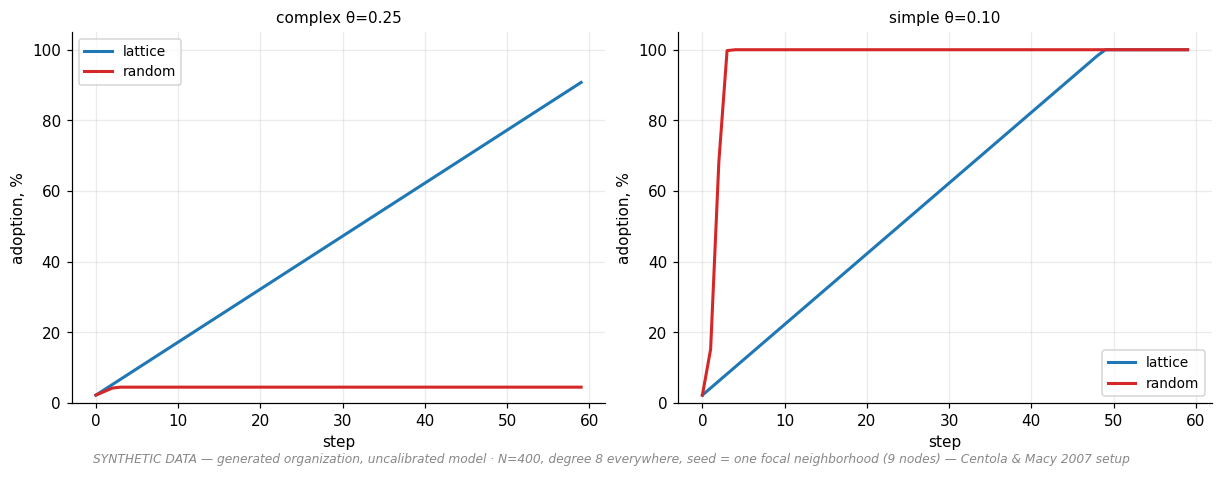

complex: lattice 100% vs random 4% · simple time-to-90%: random 3 steps vs lattice 44 → PASS


In [3]:
N = 400
lat_g = nx.watts_strogatz_graph(N, 8, p=0.0, seed=1)            # pure ring lattice
rnd_g = nx.random_regular_graph(8, N, seed=1)                   # degree-matched random
lattice, randomg = wrap(lat_g), wrap(rnd_g)
ego = {"lattice": seeds(0, *lat_g.neighbors(0)),                # focal node + its
       "random": seeds(0, *rnd_g.neighbors(0))}                 # whole neighborhood

runs = {}
for name, g in (("lattice", lattice), ("random", randomg)):
    for label, th in (("complex θ=0.25", 0.25), ("simple θ=0.10", 0.10)):
        runs[(name, label)] = run_simulation(g, PARAMS_FAST, ego[name], rng=2,
                                             agents=exact_agents(N, th))

fig, axes = plotting.fig_with_stamp(1, 2, figsize=(11, 4.2),
    note="N=400, degree 8 everywhere, seed = one focal neighborhood (9 nodes) — Centola & Macy 2007 setup")
for ax, kind in zip(axes, ("complex θ=0.25", "simple θ=0.10")):
    for name, color in (("lattice", "#1f77b4"), ("random", "#d62728")):
        ax.plot(100 * runs[(name, kind)].curve[:60], lw=2, color=color, label=name)
    ax.set_title(f"{kind}", fontsize=10)
    ax.set_xlabel("step"); ax.set_ylabel("adoption, %"); ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
plt.show()

cx_lattice = runs[("lattice", "complex θ=0.25")].final_rate
cx_random = runs[("random", "complex θ=0.25")].final_rate
sp_lattice_t = np.argmax(runs[("lattice", "simple θ=0.10")].curve >= 0.9)
sp_random_t = np.argmax(runs[("random", "simple θ=0.10")].curve >= 0.9)
ok = cx_lattice > 0.9 and cx_random < 0.1 and sp_random_t < sp_lattice_t
VERDICTS["centola_macy_bridges"] = "PASS" if ok else "FAIL"
print(f"complex: lattice {cx_lattice:.0%} vs random {cx_random:.0%} · "
      f"simple time-to-90%: random {sp_random_t} steps vs lattice {sp_lattice_t} → {VERDICTS['centola_macy_bridges']}")

## Check 3 — Watts (2002): the cascade boundary

Random 8-regular graph, a **single seeded adopter**, homogeneous thresholds. Watts:
global cascades require early adopters convertible by *one* neighbor — θ < 1/z = 0.125.
We run 10 populations on each side of the boundary. **Expected:** θ = 0.10 sometimes
cascades globally; θ = 0.15 never goes anywhere.

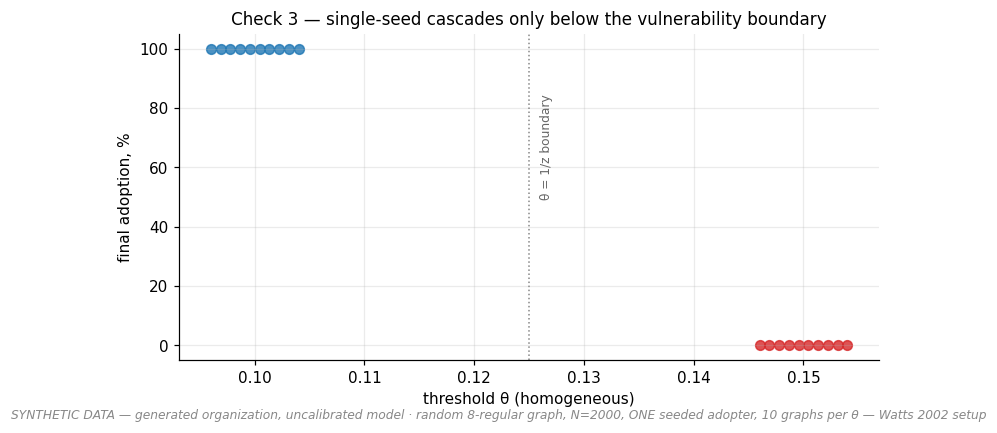

θ=0.10: 10/10 global cascades · θ=0.15: max 0.1% → PASS


In [4]:
finals = {0.10: [], 0.15: []}
for th in finals:
    for s in range(10):
        g = wrap(nx.random_regular_graph(8, 2000, seed=100 + s))
        r = run_simulation(g, PARAMS_FAST, seeds(0), rng=s, agents=exact_agents(2000, th))
        finals[th].append(r.final_rate)

fig, ax = plotting.fig_with_stamp(figsize=(7, 3.8),
    note="random 8-regular graph, N=2000, ONE seeded adopter, 10 graphs per θ — Watts 2002 setup")
for i, (th, vals) in enumerate(finals.items()):
    x = np.full(len(vals), th) + np.linspace(-0.004, 0.004, len(vals))
    ax.scatter(x, 100 * np.array(vals), s=40,
               color="#1f77b4" if th < 0.125 else "#d62728", alpha=0.8)
ax.axvline(1 / 8, color="#888888", linestyle=":", lw=1)
ax.text(0.126, 50, "θ = 1/z boundary", fontsize=8, color="#666666", rotation=90)
ax.set_xlabel("threshold θ (homogeneous)"); ax.set_ylabel("final adoption, %")
ax.set_title("Check 3 — single-seed cascades only below the vulnerability boundary", fontsize=11)
plt.show()
ok = max(finals[0.10]) > 0.9 and max(finals[0.15]) < 0.01
VERDICTS["watts_cascade_boundary"] = "PASS" if ok else "FAIL"
print(f"θ=0.10: {sum(v > 0.9 for v in finals[0.10])}/10 global cascades · "
      f"θ=0.15: max {max(finals[0.15]):.1%} → {VERDICTS['watts_cascade_boundary']}")

## Sensitivity — which knobs move the headline result?

One-at-a-time tornado (spec §2.3) around the headline **cluster-seeding** scenario:
each parameter pushed to a low and a high value, 10 fresh-organization replicates each,
plateau recorded. Long bars = assumptions that carry the result; they get priority in
[`docs/decisions.md`](../docs/decisions.md) arbitration. Note `p_innovator` low side = 0
— the "no innovators" variant flagged in D16.

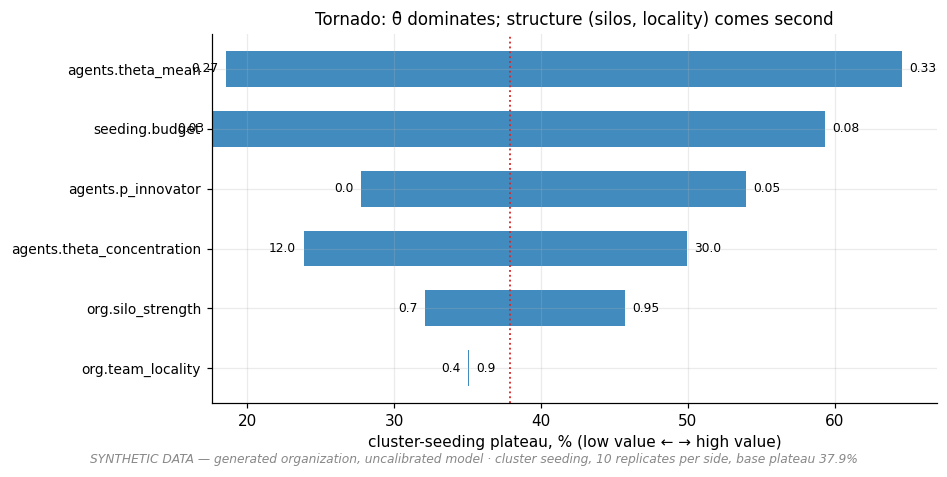

agents.theta_mean            swing  46.0 pp   (0.27 → 0.33)
seeding.budget               swing  41.8 pp   (0.03 → 0.08)
agents.p_innovator           swing  26.2 pp   (0.0 → 0.05)
agents.theta_concentration   swing  26.1 pp   (12.0 → 30.0)
org.silo_strength            swing  13.6 pp   (0.7 → 0.95)
org.team_locality            swing   0.1 pp   (0.4 → 0.9)


In [5]:
from core.sweep import tornado
SC = exp1.headline_scenario()
PERTURB = {
    "agents.theta_mean": (0.27, 0.33),
    "agents.theta_concentration": (12.0, 30.0),
    "org.silo_strength": (0.70, 0.95),
    "org.team_locality": (0.40, 0.90),
    "seeding.budget": (0.03, 0.08),
    "agents.p_innovator": (0.0, 0.05),
}
tor = tornado(SC, PERTURB, replicates=10)
fig, ax = plotting.fig_with_stamp(figsize=(8.5, 4.2),
    note=f"cluster seeding, 10 replicates per side, base plateau {tor[0]['base_mean']:.1%}")
ys = np.arange(len(tor))
for y, row in zip(ys, tor):
    lo, hi = sorted((row["low_mean"], row["high_mean"]))
    ax.barh(y, (hi - lo) * 100, left=lo * 100, color="#1f77b4", height=0.6, alpha=0.85)
    ax.text(lo * 100 - 0.5, y, f"{row['low_value']}", ha="right", va="center", fontsize=8)
    ax.text(hi * 100 + 0.5, y, f"{row['high_value']}", ha="left", va="center", fontsize=8)
ax.axvline(tor[0]["base_mean"] * 100, color="#d62728", linestyle=":", lw=1.2)
ax.set_yticks(ys, [r["param"] for r in tor], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("cluster-seeding plateau, % (low value ← → high value)")
ax.set_title("Tornado: θ̄ dominates; structure (silos, locality) comes second", fontsize=11)
plotting.save_fig(fig, REPO / "figures" / "exp2_tornado.png")
plt.show()
for r in tor:
    print(f"{r['param']:<28} swing {r['swing']*100:5.1f} pp   ({r['low_value']} → {r['high_value']})")

## Robustness — does the headline survive uniform credibility weights?

Decision **D3** stipulates peer > manager > comms credibility. The null model sets every
weight to 1.0 (including comms). If the broadcast-vs-cluster gap needed the weight
table to exist, the headline would be an artifact of D3.

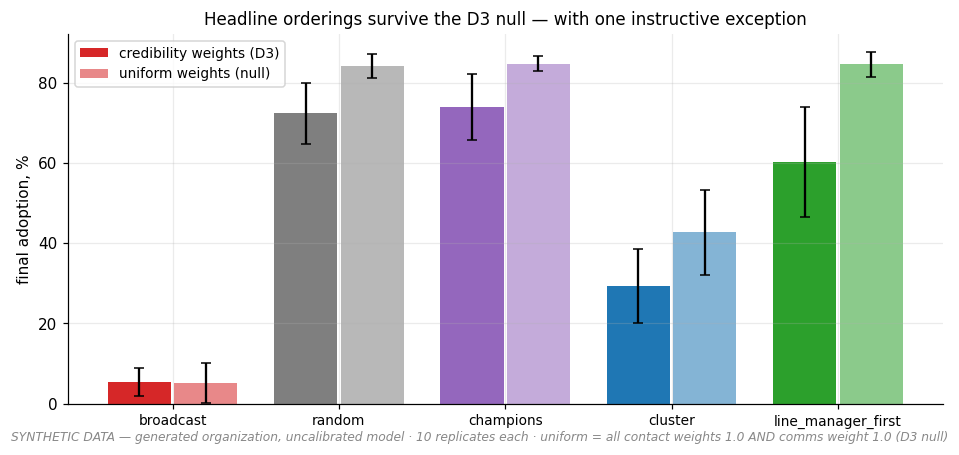

uniform weights: broadcast 5.2% vs cluster 42.7% → PASS
note: comms at weight 1.0 makes broadcast a *bigger* nudge (share 1/(W+1) ≈ 0.08),
yet still below almost everyone's threshold — broadcast fails for threshold reasons, not weighting.


In [6]:
from core.sweep import expand_jobs, sweep
uni = set_path(SC, "org.weights",
               {"peer_close": 1.0, "peer_far": 1.0, "manager_report": 1.0, "comms": 1.0})
uni = set_path(uni, "dynamics.w_comms", 1.0)
uni["meta"]["name"] = "uniform-weights"
rows_u = sweep(expand_jobs(uni, {"seeding.strategy": exp1.STRATEGY_ORDER}, replicates=10))
rows_h = sweep(expand_jobs(SC, {"seeding.strategy": exp1.STRATEGY_ORDER}, replicates=10))

fig, ax = plotting.fig_with_stamp(figsize=(8.5, 4),
    note="10 replicates each · uniform = all contact weights 1.0 AND comms weight 1.0 (D3 null)")
x = np.arange(len(exp1.STRATEGY_ORDER))
for off, rows, label, alpha in ((-0.2, rows_h, "credibility weights (D3)", 1.0),
                                (0.2, rows_u, "uniform weights (null)", 0.55)):
    means = [np.mean([r["final_rate"] for r in rows if r["strategy"] == s]) * 100
             for s in exp1.STRATEGY_ORDER]
    sds = [np.std([r["final_rate"] for r in rows if r["strategy"] == s]) * 100
           for s in exp1.STRATEGY_ORDER]
    ax.bar(x + off, means, width=0.38, yerr=sds, capsize=3, label=label, alpha=alpha,
           color=[plotting.STRATEGY_COLORS[s] for s in exp1.STRATEGY_ORDER])
ax.set_xticks(x, exp1.STRATEGY_ORDER, fontsize=9)
ax.set_ylabel("final adoption, %")
ax.set_title("Headline orderings survive the D3 null — with one instructive exception", fontsize=11)
ax.legend(fontsize=9)
plt.show()

bc_u = np.mean([r["final_rate"] for r in rows_u if r["strategy"] == "broadcast"])
cl_u = np.mean([r["final_rate"] for r in rows_u if r["strategy"] == "cluster"])
ok = bc_u < cl_u
VERDICTS["headline_survives_uniform_weights"] = "PASS" if ok else "FAIL"
print(f"uniform weights: broadcast {bc_u:.1%} vs cluster {cl_u:.1%} → {VERDICTS['headline_survives_uniform_weights']}")
print("note: comms at weight 1.0 makes broadcast a *bigger* nudge (share 1/(W+1) ≈ 0.08),")
print("yet still below almost everyone's threshold — broadcast fails for threshold reasons, not weighting.")

## Real topology — the Enron e-mail graph (demonstration only)

**What is real here: the edges.** 36,692 addresses, 183,831 e-mail ties (SNAP,
`email-Enron`). **Everything else is synthetic**: thresholds, willingness, credibility
weights, "teams" (Louvain communities), and there are no roles — this run says nothing
about Enron and is **not** a calibration (limitations.md #11). It demonstrates the
engine on a real, heavy-tailed, clustered topology — degree here ranges from 1 to
~1,400, unlike our generator's tame teams.

> This cell needs `data/raw/email-Enron.txt.gz` — fetch it with
> `python experiments/fetch_enron.py` (~1.8 MB). Without it the cell skips itself;
> nothing else in the notebook depends on it.

36692 nodes · mean degree 10.0 · max degree 1383 · 1243 Louvain communities


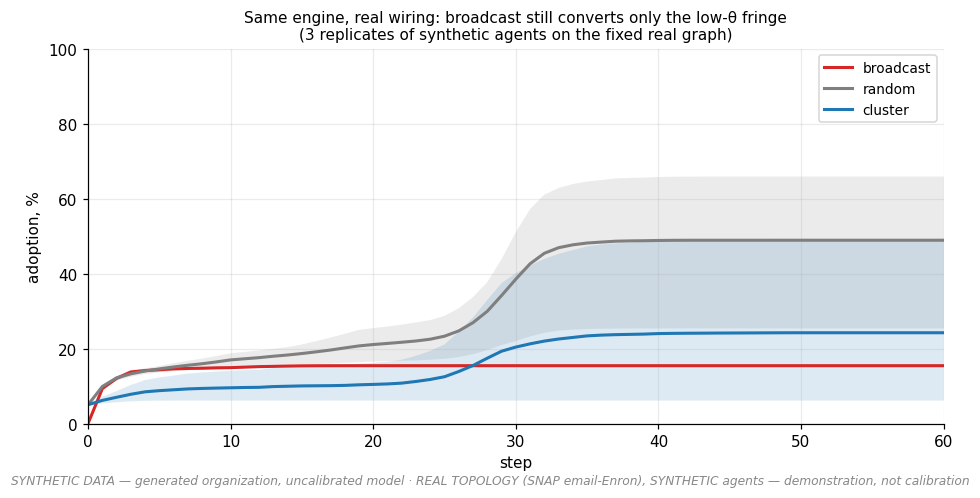

broadcast    final 15.4%
random       final 48.9%
cluster      final 24.2%
elapsed 58s


In [7]:
enron_path = REPO / "data" / "raw" / "email-Enron.txt.gz"
if not enron_path.exists():
    print("email-Enron.txt.gz not found — skipping (python experiments/fetch_enron.py to fetch).")
else:
    from core.ingest import load_edgelist, as_org
    org_e = as_org(load_edgelist(enron_path), source="snap-email-enron")
    ce = org_e.compile()
    print(f"{ce.n} nodes · mean degree {ce.degrees().mean():.1f} · max degree {ce.degrees().max()} · "
          f"{org_e.params['n_communities']} Louvain communities")
    params_e = build_sim_params(SC)   # headline agent parameters, synthetic
    fig, ax = plotting.fig_with_stamp(figsize=(8.5, 4.4),
        note="REAL TOPOLOGY (SNAP email-Enron), SYNTHETIC agents — demonstration, not calibration")
    table = []
    for strat in ("broadcast", "random", "cluster"):
        stack = []
        for rep in range(3):
            rng = np.random.default_rng((7, rep))
            seeding = make_seeding(strat, ce, 0.05, rng=rng)
            r = run_simulation(ce, params_e, seeding, rng=rng)
            stack.append(r.curve)
        mean, lo, hi = exp1.band(np.array(stack))
        plotting.plot_curve_band(ax, mean, lo, hi, strat, plotting.STRATEGY_COLORS[strat])
        table.append((strat, mean[-1]))
    ax.set_xlim(0, 60); ax.set_ylim(0, 100)
    ax.set_xlabel("step"); ax.set_ylabel("adoption, %")
    ax.set_title("Same engine, real wiring: broadcast still converts only the low-θ fringe\n"
                 "(3 replicates of synthetic agents on the fixed real graph)", fontsize=10)
    ax.legend(fontsize=9)
    plt.show()
    for strat, f in table:
        print(f"{strat:<12} final {f:.1%}")
    print(f"elapsed {time.time()-T0:.0f}s")

## Verdicts

Mirrored (with numbers and dates) in [`docs/sanity-checks.md`](../docs/sanity-checks.md).
For balance, the model also has **documented non-reproductions** — things the
literature or folklore expects that this model family does *not* show, reported in
notebook 01 and `docs/decisions.md`: the "always seed clusters" heuristic (D16), the
spike-then-relapse curve shape (D7 amendment), and individual pivot relays in
generated organizations (D12 amendment). A simulator you can trust is one that shows
you where it disagrees with you.

In [8]:
# --- provenance footer (release standard) ---
import platform, numpy, networkx
print("=" * 72)
print("PROVENANCE — experiment 2 (sanity checks)")
print("checks use exact thresholds + fixed seeds; tornado/null-model sweeps use the headline scenario master seed")
print("decision log: D1-D17 RATIFIED 2026-06-10 (docs/decisions.md)")
print(f"adoption-sim {core.__version__} · numpy {numpy.__version__} · networkx {networkx.__version__} · python {platform.python_version()}")
print("ALL DATA SYNTHETIC (Enron section: real topology, synthetic agents) — see docs/limitations.md")
print(f"{'check':<38}{'verdict':>8}")
for k, v in VERDICTS.items():
    print(f"{k:<38}{v:>8}")
print(f"total runtime: {time.time()-T0:.0f}s")

PROVENANCE — experiment 2 (sanity checks)
checks use exact thresholds + fixed seeds; tornado/null-model sweeps use the headline scenario master seed
decision log: D1-D17 RATIFIED 2026-06-10 (docs/decisions.md)
adoption-sim 0.1.0 · numpy 2.4.6 · networkx 3.6.1 · python 3.13.13
ALL DATA SYNTHETIC (Enron section: real topology, synthetic agents) — see docs/limitations.md
check                                  verdict
granovetter_knife_edge                    PASS
centola_macy_bridges                      PASS
watts_cascade_boundary                    PASS
headline_survives_uniform_weights         PASS
total runtime: 58s
